# Final project 

Building on the previous project you are asked to produce an evaluation of the insulation needs for a facility storing snow for two different locations: Lake Placid, NY and Soldier Hollow, UT. The goal is to store enough snow of the period April to October for a 5km-long, 10-m wide, 0.5m thick XC ski trail in November. This notebook allows of the calculation of snow height loss based on the weather of either location. Dimensions of the building are provided in the overleaf document. Your only coding should about making figures. Each simulation is saved into a file, whose name contains the number of the wall, and the location. Examples are provided for how to read the files and what variables are saved.




In [1]:
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import math
import scipy.constants as sc
from scipy.constants import convert_temperature
from scipy.optimize import fsolve
import h5py

import sympy as sym
import sys

    
font = {'family' : 'serif',
        #'color'  : 'black',
        'weight' : 'normal',
        'size'   : 16,
        }
fontlabel = {'family' : 'serif',
        #'color'  : 'black',
        'weight' : 'normal',
        'size'   : 16,
        }

from matplotlib.ticker import FormatStrFormatter
plt.rc('font', **font)
from Libraries import numericsv2 as num
import weathertools as wtools
oneminute = 60.
onehour = 3600.0
oneday = 24*onehour
oneweek = 7*oneday

In [2]:
import pandas as pd
#====== Choose your location ======
loc = 'Lake Placid, NY'
# loc = 'Soldier Hollow, UT'
weather = pd.read_excel("Climate/April-October-2020.xlsx",
                        sheet_name=loc,header=0,
                        converters= {'Date time': pd.to_datetime},)
weather = weather.set_index('Date time')

weatherfct = wtools.WeatherData(weather)
weather['Name'].head(1)


Date time
2020-04-01    Lake Placid, NY, United States
Name: Name, dtype: object


# 1D steady state and transient simulation of pure conduction through a plane wall made out of a single material

The library `numericsv2` solves the 1D, pure conduction heat equation in plane wall for steady and unsteady states with Dirichlet (fixed temperature) and Neumann (fixed flux) boundary conditions.
\begin{align}
\text{Heat equation: }& \rho C_p\frac{\partial T}{\partial t} = k\frac{\partial^2 T}{\partial x^2}\text{ for }x_0\leq x\leq x_1\text{ and } t>0\\
\text{Dirichlet bc: }& T(x=x_0\text{ or }x_1,t)=T_\mathrm{bc}(t)\\
\text{Neumann bc: }& q''(x=x_0\text{ or }x_1,t)=\left.-k\frac{\partial T}{\partial x}\right\vert_{x=x_0\text{ or }x_1,t}=q''_\mathrm{bc}(t)\\
\end{align}

## Definition of variables availables in dump files

Dump files are named `wallxx_loc=yyyy.h5` where `xx` is the wall number (see below) and `yyyy` the location. They store the following variables:
* `'t'` time in second at which data was collected. 1D array of dimension $N_{samples}$
* `'H_t'`: height of enclosure for all collected instances. 1D array of dimension $N_{samples}$
* `'xs'`: Location of computational nodes used to discretize the roof. 1D array of dimension $N_{nodes}$
* `'enthalpy'`: total enthalpy of the roof for all collected instances. 1D array of dimension $N_{samples}$
* `'Tprofiles'`: profiles of temperatures within the roof for all collected instances. 2D array of dimensions $(N_{samples},N_{nodes})$ where $N_{nodes}$ is the number of computational nodes used to discretize the roof.
* `'qppx0and1'`: wall heat fluxes for all collected instances. 2D array of dimensions $(N_{samples},2)$ where the second index is for inner $i=0$ or outer $i=1$ roof surfaces.
* `'k'`: Distribution of thermal conductivity of the computational nodes. 1D array of dimension $N_{nodes}$
* `'rhoCp'`: Distribution of product density by specific heat of the computational nodes. 1D array of dimension $N_{nodes}$

## Definition of variables availables in object `weatherfct`
All functions provide information at any time $t$ within the period over which weather data is available.
* `weatherfct.U_atmospheric(t)` : wind speed
* `weatherfct.T_atmospheric(t)` : Ambiant temperature
* `weatherfct.sun_irradiation(t)` : Solar irradiation
* `weatherfct.cloud_cover(t)` : cloud cover
* `weatherfct.dew_point(t)` : dew point temperature
* `weatherfct.relative_humidity(t)` : relative humidity
* `weatherfct.rain_rate(t)` : rain rate

and the radiation to the sky, outside convection, and heat transfer by train fluxes are given by the functions:
* `weatherfct.qpp_skyradiation(t,wall.T[-1])` where `wall.T[-1]` is the roof's outer surface temperature.
* `weatherfct.qpp_outsideconvection(t,wall.T[-1],Length)`
* `weatherfct.qpp_rain(t,wall.T[-1])`

## Definition of thermodynamic properties of wall materials

In [3]:
rhodict = {}; kdict = {}; Cpdict = {}; alphadict = {}
# Polystyrene expanded extruded
rhodict['xps'] = 55 #kg/m^3
kdict['xps'] = 0.027 #W/m.K
Cpdict['xps'] = 1210 #J/kg.K
alphadict['xps'] = kdict['xps']/(rhodict['xps']*Cpdict['xps'])
print("Thermal diffusivity of XPS: %.2e m^2/s" %alphadict['xps'])

# Soft solid wood
rhodict['swood'] = 510 #kg/m^3
kdict['swood'] = 0.12 #W/m.K
Cpdict['swood'] = 1380 #J/kg.K
alphadict['swood'] = kdict['swood']/(rhodict['swood']*Cpdict['swood'])
print("Thermal diffusivity of soft wood: %.2e m^2/s" %alphadict['swood'])

# Compressed wood fiber
# https://www.betonwood.com/eng/wood-fiber-therm.html
rhodict['woodfiber'] = 160 #kg/m^3
kdict['woodfiber'] = 0.038 #W/m.K
Cpdict['woodfiber'] = 2100 #J/kg.K
alphadict['woodfiber'] = kdict['woodfiber']/(rhodict['woodfiber']*Cpdict['woodfiber'])
print("Thermal diffusivity of compressed wood fiber: %.2e m^2/s" %alphadict['woodfiber'])

# https://www.betonwood.com/eng/wood-fiber-flex60.html
rhodict['woodfiber60'] = 60 #kg/m^3
kdict['woodfiber60'] = 0.036 #W/m.K
Cpdict['woodfiber60'] = 2100 #J/kg.K
alphadict['woodfiber60'] = kdict['woodfiber60']/(rhodict['woodfiber60']*Cpdict['woodfiber60'])
print("Thermal diffusivity of compressed wood fiber flex 60: %.2e m^2/s" %alphadict['woodfiber60'])
# Concrete
rhodict['concrete'] = 1860 #kg/m^3
kdict['concrete'] = 0.72 #W/m.K
Cpdict['concrete'] = 780 #J/kg.K
alphadict['concrete'] = kdict['concrete']/(rhodict['concrete']*Cpdict['concrete'])
print("Thermal diffusivity of concrete: %.2e m^2/s" %alphadict['concrete'])

#Hempcrete
rhodict['hempcrete'] = 460 #kg/m^3
kdict['hempcrete'] = 0.08 #W/m.K
Cpdict['hempcrete'] = 1400 #J/kg.K
alphadict['hempcrete'] = kdict['hempcrete']/(rhodict['hempcrete']*Cpdict['hempcrete'])
print("Thermal diffusivity of hempcrete: %.2e m^2/s" %alphadict['hempcrete'])

Thermal diffusivity of XPS: 4.06e-07 m^2/s
Thermal diffusivity of soft wood: 1.71e-07 m^2/s
Thermal diffusivity of compressed wood fiber: 1.13e-07 m^2/s
Thermal diffusivity of compressed wood fiber flex 60: 2.86e-07 m^2/s
Thermal diffusivity of concrete: 4.96e-07 m^2/s
Thermal diffusivity of hempcrete: 1.24e-07 m^2/s


In [60]:
weatherfct.t[-1]/oneday

213.0

## Definition of wall compositions
Feel free to add your own composition by adding a case or two. All you need is to specify your materials and the thickness of each materials.

In [4]:
def build_layers(Nlayers,thicknesses):
    xlayers = np.zeros((Nlayers,2))
    xlayers[0,1] = thicknesses[0]
    if Nlayers > 1:
        for n in range(1,Nlayers):
            xlayers[n,0] = xlayers[n-1,1]
            xlayers[n,1] = xlayers[n,0] + thicknesses[n]

    return xlayers
def wall_definition(wallnumber):
    match wallnumber:
        case 0:
            materials = ['swood', 'concrete']
            thicknesses = np.array([0.005,0.05])
            Nnodes = np.array([5,21])
            Nlayers = len(materials)
            xlayers = build_layers(Nlayers,thicknesses)
        #========================
        case 1:
            materials = ['swood', 'xps', 'concrete']
            thicknesses = np.array([0.005,0.025,0.05])
            Nnodes = np.array([5,15,21])
            Nlayers = len(materials)
            xlayers = build_layers(Nlayers,thicknesses)
        #========================
        case 2:
            materials = ['swood', 'xps', 'hempcrete']
            thicknesses = np.array([0.005,0.025,0.05])
            Nnodes = np.array([5,15,21])
            Nlayers = len(materials)
            xlayers = build_layers(Nlayers,thicknesses)
        #========================
        case 3:
            materials = ['swood', 'xps', 'concrete']
            thicknesses = np.array([0.005,0.025,0.1])
            Nnodes = np.array([5,15,41])
            Nlayers = len(materials)
            xlayers = build_layers(Nlayers,thicknesses)
        #========================
        case 4:
            materials = ['swood', 'xps', 'hempcrete']
            thicknesses = np.array([0.005,0.025,0.1])
            Nnodes = np.array([5,15,41])
            Nlayers = len(materials)
            xlayers = build_layers(Nlayers,thicknesses)
    return materials,thicknesses,Nnodes,Nlayers,xlayers
    return materials,thicknesses,Nnodes,Nlayers,xlayers


# Simulation
The only modification you need to make is the variable wall number. It takes at most 400s on a new M4 chip. The code will give you an estimate of the time remaining in the simulations.

In [5]:
from Libraries import thermodynamics as thermo
from Libraries import HT_external_convection as extconv
from Libraries import HT_natural_convection as natconv
from Libraries import HT_thermal_resistance as res
import time
dt = 60
dump_time_period = 15*oneminute
dump_status_period = oneday
ts = 0
#====== t start ======
t = tstart = 0*oneday
#=====================
# tend =   10 * oneday + tstart # 
tend = weatherfct.t[-1]

#====== Wall choice ====== 

wallnumber = 0

#====== ====== ====== ====== 
materials,thicknesses,Nnodes,Nlayers,xlayers = wall_definition(wallnumber)
dxmin = 0.0001 # do not modify

# ====== Enclosure dimensions at t=0 ======
H_t = 3.0 # height at t=0, will change over time

Width = 50.0
Length = 100.0

# ====== snow properties ======
rhotimesh_l_snow = 600*3e5
# ====== Initialization t= 0 ======
# Compute a temperature profile obtained by solving steady state heat transfer based on T(x0)=0.0 and T(x1)=T_atm(t)
T0 = 0.0 # assumes inner wall at 
T1 = weatherfct.T_atmospheric(tstart)# assumes outer wall at atmopsheric temperature
print(T1)
bcnames = ['Dirichlet', 'Dirichlet']
wall = num.ConductionDomain(Nlayers,xlayers,bcnames)
wall.create_grid(Nnodes,dxmin)
wall.set_layers_thermodynamic_properties(k_per_layer=[kdict[prop] for prop in materials], 
                                         rho_per_layer=[rhodict[prop] for prop in materials], 
                                         Cp_per_layer=[Cpdict[prop] for prop in materials],
                                         qdot_per_layer=np.zeros(Nlayers))
wall.bc.set_value('x0',T0)
wall.bc.set_value('x1',T1)
wall.create_metrics()
Tinit = T1*np.ones_like(wall.grid.xs)
wall.init_T(Tinit)
wall.solve_steady()
Tinit = wall.T.copy() # Initial temperature boundary conditions 

# ===== Unsteady simulation =====
# bcnames = ['Dirichlet', 'Neumann']
bcnames = ['Neumann', 'Neumann']
wall = num.ConductionDomain(Nlayers,xlayers,bcnames)
wall.create_grid(Nnodes,0.0005)
wall.set_layers_thermodynamic_properties(k_per_layer=[kdict[prop] for prop in materials], 
                                         rho_per_layer=[rhodict[prop] for prop in materials], 
                                         Cp_per_layer=[Cpdict[prop] for prop in materials],
                                         qdot_per_layer=np.zeros(Nlayers))
wall.bc.set_value('x0',T0)
wall.bc.set_value('x1',0.0)
wall.create_metrics()
wall.init_T(Tinit)


numberofdays = int((tend - tstart)/oneday)
iteration = 0
Niterations = int((tend - tstart) / dt)
wall.dump = num.Dump(t,wall.T,H_t,wall.k,wall.rhoCp,wall.grid.xs,wall.metrics.Dx,initialize=True)
tstatus = 0.
cputime_start = time.time()
qpp_x1 = 0.0
qpp_clipmin = -1000.0
qpp_clipmax = 5.0
skip = False
while t < tend:
    T_old = wall.T.copy()
    qpp_x1_old = qpp_x1
    try:
        qpp_x1 = -0.8*weatherfct.sun_irradiation(t)
        if weatherfct.sun_irradiation(t) <= 2.:
            eps = 0.1
        else:
            eps = 1.0
        qpp_x1 += eps*weatherfct.qpp_skyradiation(t,wall.T[-1])
        qpp_x1 += weatherfct.qpp_outsideconvection(t,wall.T[-1],Length)
        qpp_x1 += weatherfct.qpp_rain(t,wall.T[-1])
    except ValueError:
        print("time step may be too high")
        skip = True
    qpp_x1 = np.clip(qpp_x1,qpp_clipmin,qpp_clipmax)
    wall.bc.set_value('x1',qpp_x1)
    Tf_enc = 0.5*(wall.T[0] + 0.0)
    air_enc = thermo.Fluid("air", Tf_enc, "C")
    DT = np.abs(wall.T[0] - 0.0)
    Ra = natconv.Ra(9.81,air_enc.beta,DT,Length+H_t,air_enc.nu,air_enc.alpha)
    enclosure = natconv.RectangularEnclosure(Ra,air_enc.Pr)
    
    h_enc = enclosure.Nu*air_enc.k/H_t
    qpp_enc = -h_enc*(wall.T[0] - 0.0)
    # print(qpp_enc,wall.T[0])
    wall.bc.set_value('x0',qpp_enc)
    wall.solve_unsteady(dt)

    H_t += dt*np.clip(h_enc*(wall.T[0] - 0.0),0.0,None)/rhotimesh_l_snow
    
    # if np.abs(wall.T[-1] - T_old[-1]) > 5:
    #     print("temperature variation is too large",qpp_x1,qpp_x1_old,qpp_x1 - qpp_x1_old,dqpp_x1 )
    
    t += dt
    ts += dt
    tstatus += dt
    iteration += 1
    if (ts >= dump_time_period):
        timeperiteration = (time.time() - cputime_start)/iteration
        Niterations_remaining = Niterations - iteration
        eta = Niterations_remaining*timeperiteration
        wall.dump.update(t,wall.T,H_t,wall.k,wall.rhoCp,wall.grid.xs,wall.metrics.Dx)
        ts = 0.
    if (tstatus >= dump_status_period):
        numberofdayscompleted = int((t - tstart)/oneday)
        print("Progress: %.3f %%, days completed: %.0f, cpu time: %.2f s" %((t - tstart)/(tend - tstart)*100, 
                                                                           numberofdayscompleted, 
                                                                           time.time() - cputime_start))
        print("Estimated time to completion: %.2f s, number of days remaining: %i" %(eta, numberofdays - numberofdayscompleted))
        tstatus = 0.
        print("Enclosure Height: %.3f m" %H_t)
        clear_output(wait=True)
wall.dump.writefile("wall%i_loc=%s.h5" %(wallnumber,''.join(loc.split())))

(20449,)


# Examples of plots

## Snow pile height loss

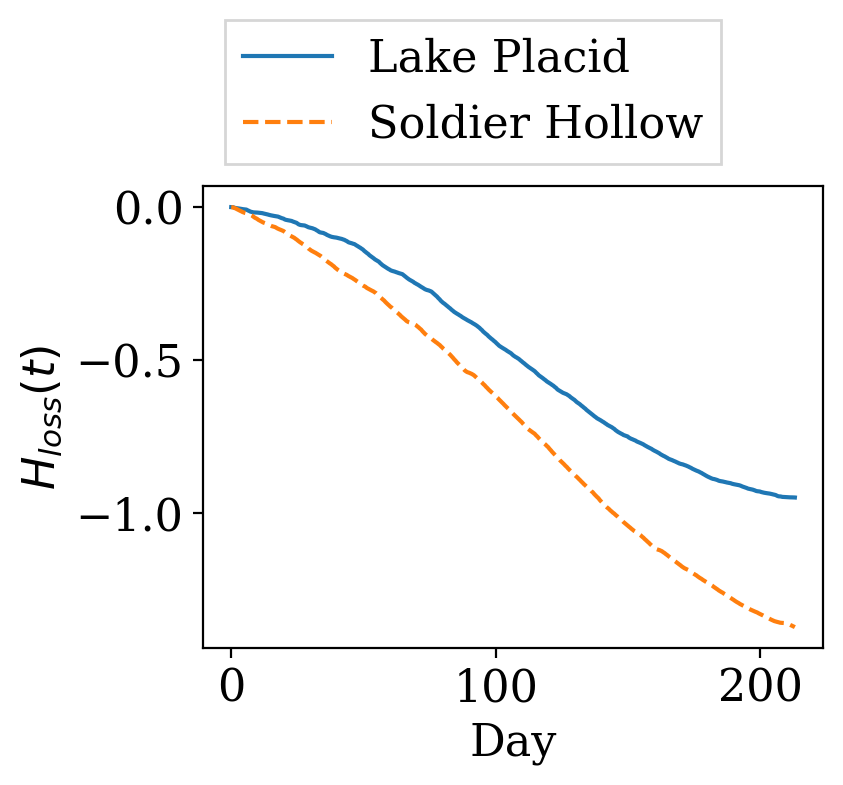

In [11]:
wallnumber = 4
loc = 'Lake Placid, NY'
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=200)
f_LP = h5py.File("wall%i_loc=%s.h5"%(wallnumber,''.join(loc.split())),"r")
plt.plot(f_LP['t'][:]/oneday,f_LP['H_t'][0] - f_LP['H_t'][:], label='Lake Placid')
f_LP.close()
loc = 'Soldier Hollow, UT'
f_SH = h5py.File("wall%i_loc=%s.h5"%(wallnumber,''.join(loc.split())),"r")
plt.plot(f_SH['t'][:]/oneday,f_SH['H_t'][0] - f_SH['H_t'][:],'--',label='Soldier Hollow')
f_SH.close()
plt.legend()
plt.xlabel('Day')
plt.ylabel("$H_{loss}(t)$")
plt.legend(loc='lower left', bbox_to_anchor=(0.0, 1.0),
          ncol=1, fancybox=False, shadow=False)
plt.show()

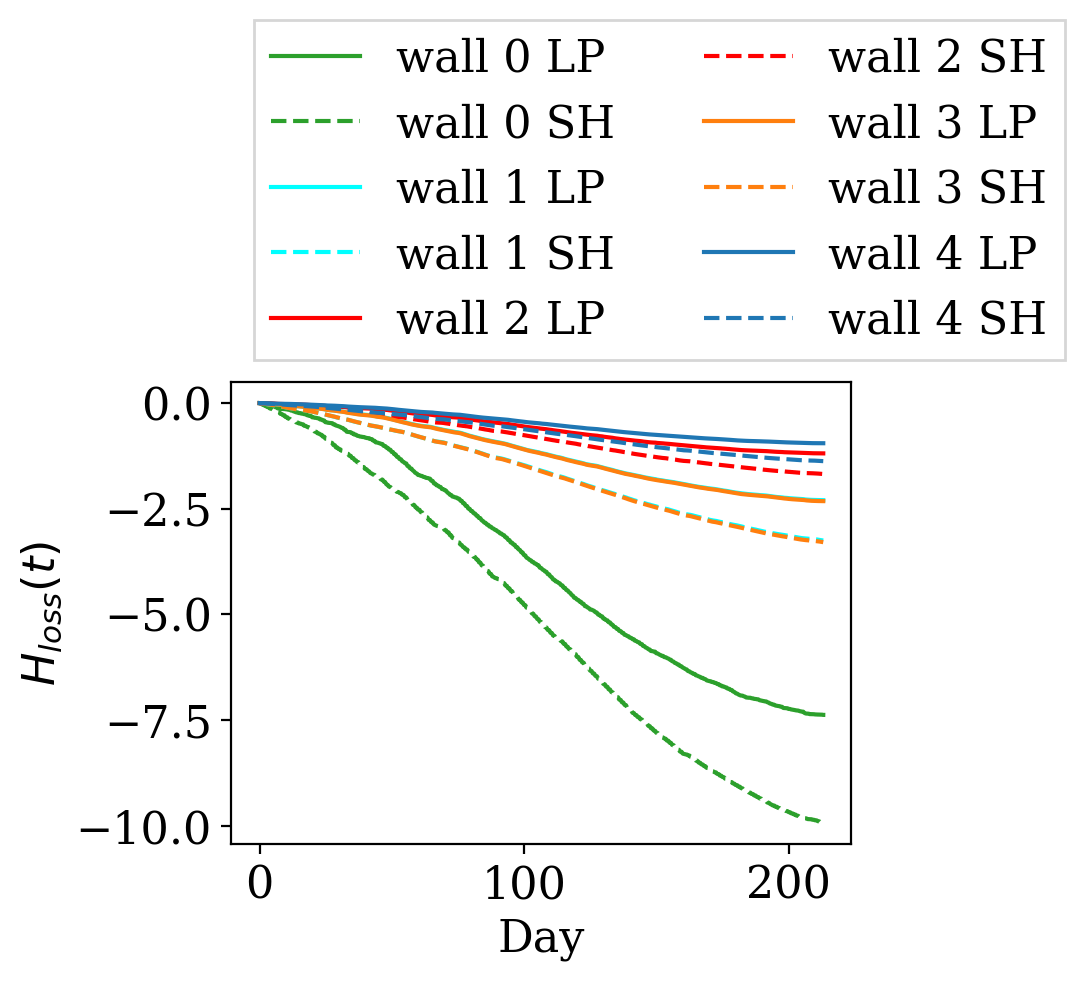

In [83]:
colors = ['tab:green', 'cyan', 'red', 'C1', 'C0']
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=200)
string = ""
for wallnumber in range(5):
    loc = 'Lake Placid, NY'
    f_LP = h5py.File("wall%i_loc=%s.h5"%(wallnumber,''.join(loc.split())),"r")
    plt.plot(f_LP['t'][:]/oneday,f_LP['H_t'][0] - f_LP['H_t'][:],ls = 'solid', c=colors[wallnumber], label="wall %i LP" %wallnumber)
    f_LP.close()
    loc = 'Soldier Hollow, UT'
    f_SH = h5py.File("wall%i_loc=%s.h5"%(wallnumber,''.join(loc.split())),"r")
    plt.plot(f_SH['t'][:]/oneday,f_SH['H_t'][0] - f_SH['H_t'][:],ls = 'dashed', c=colors[wallnumber], label="wall %i SH" %wallnumber)
    f_SH.close()
    string +=str(wallnumber)
plt.legend()
plt.xlabel('Day')
plt.ylabel("$H_{loss}(t)$")
plt.legend(loc='lower left', bbox_to_anchor=(0.0, 1.0),
          ncol=2, fancybox=False, shadow=False)
plt.savefig("Hloss_%s.png" %string,bbox_inches='tight')
plt.show()

## Comparison solar irradiation heat flux on roof's inner surface.

In [7]:
loc = 'Lake Placid, NY'

weather = pd.read_excel("Climate/April-October-2020.xlsx",
                        sheet_name=loc,header=0,
                        converters= {'Date time': pd.to_datetime},)
weather = weather.set_index('Date time')

weatherfct_LP = wtools.WeatherData(weather)
loc = 'Soldier Hollow, UT'
weather = pd.read_excel("Climate/April-October-2020.xlsx",
                        sheet_name=loc,header=0,
                        converters= {'Date time': pd.to_datetime},)
weather = weather.set_index('Date time')

weatherfct_SH = wtools.WeatherData(weather)

In [ ]:
## Lake Placid

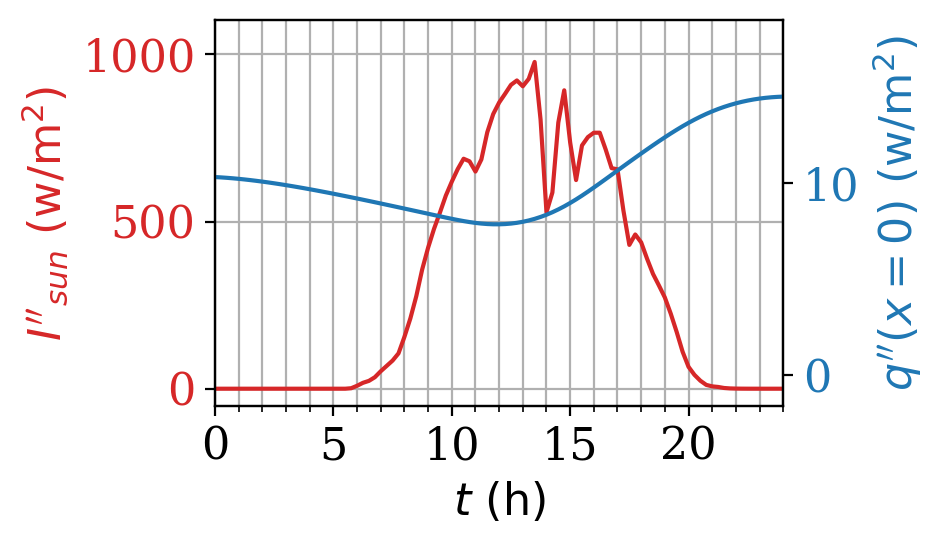

In [9]:
loc = 'Lake Placid, NY'
locnospace = ''.join(loc.split())
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
t0 = 105*oneday
t1 = 1*oneday + t0
tmid = 0.5*(t0 + t1)
thalf = (t1 - t0)/2
fig, ax1 = plt.subplots(figsize=(5,3),dpi=200)

wallnumber = 6
f_LP = h5py.File("wall%i_loc=%s.h5"%(wallnumber,''.join(loc.split())),"r")
t = f_LP['t'][:].copy()
qppx0 = f_LP['qppx0and1'][:,0].copy()
color = 'tab:red'
ax1.set_xlabel("$t~(\mathrm{h})$")
ax1.set_ylabel("$I''_{sun}~(\mathrm{w/m^2})$", color=color)
mask = np.where(np.abs(f_LP['t'][:] - tmid) <= thalf)
ax1.plot((t - t0)/onehour,weatherfct_LP.sun_irradiation(t), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(0,(t1 - t0)/onehour)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel(r"$q''(x=0)~(\mathrm{w/m^2})$", color=color)  # we already handled the x-label with ax1
qppx0 = f_LP['qppx0and1'][:,0]
ax2.plot((t - t0)/onehour,-qppx0, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_locator(MultipleLocator(5))
ax1.xaxis.set_major_formatter('{x:.0f}')

# For the minor ticks, use no labels; default NullFormatter.
ax1.xaxis.set_minor_locator(MultipleLocator(1))
ax1.grid(True, which='both')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig("fluxcomp%s.png"%locnospace,bbox_inches="tight")
plt.show()
f_LP.close()

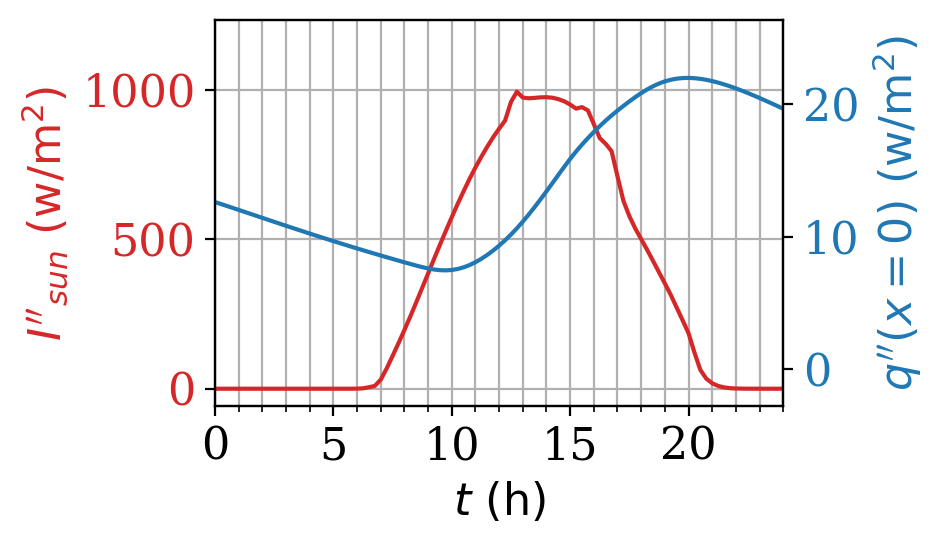

In [113]:
loc = 'Soldier Hollow, UT'
locnospace = ''.join(loc.split())
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
t0 = 105*oneday
t1 = 1*oneday + t0
tmid = 0.5*(t0 + t1)
thalf = (t1 - t0)/2
fig, ax1 = plt.subplots(figsize=(5,3),dpi=200)

wallnumber = 4
loc = 'Lake Placid, NY'
f_SH = h5py.File("wall%i_loc=%s.h5"%(wallnumber,''.join(loc.split())),"r")
t = f_SH['t'][:].copy()
qppx0 = f_SH['qppx0and1'][:,0].copy()
color = 'tab:red'
ax1.set_xlabel("$t~(\mathrm{h})$")
ax1.set_ylabel("$I''_{sun}~(\mathrm{w/m^2})$", color=color)
mask = np.where(np.abs(f_SH['t'][:] - tmid) <= thalf)
ax1.plot((t - t0)/onehour,weatherfct_SH.sun_irradiation(t), color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(0,(t1 - t0)/onehour)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel(r"$q''(x=0)~(\mathrm{w/m^2})$", color=color)  # we already handled the x-label with ax1
qppx0 = f_SH['qppx0and1'][:,0]
ax2.plot((t - t0)/onehour,-qppx0, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_locator(MultipleLocator(5))
ax1.xaxis.set_major_formatter('{x:.0f}')

# For the minor ticks, use no labels; default NullFormatter.
ax1.xaxis.set_minor_locator(MultipleLocator(1))
ax1.grid(True, which='both')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig("fluxcomp%s.png"%locnospace,bbox_inches="tight")
plt.show()
f_SH.close()

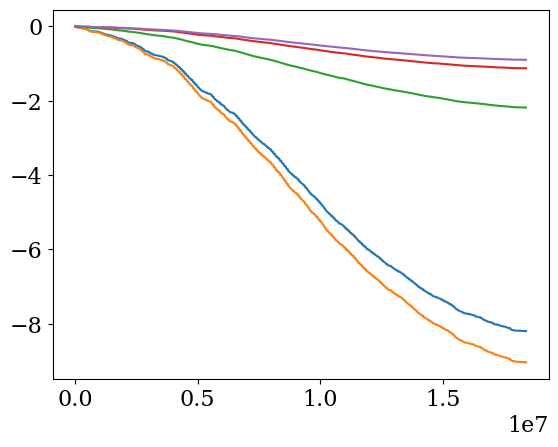

In [141]:
loc = 'Lake Placid, NY'
fig, ax = plt.subplots(1,1,figsize=(4,3),dpi=200)
for wallnumber in range(5):
    f_LP = h5py.File("wall%i_loc=%s.h5"%(wallnumber,''.join(loc.split())),"r")
    plt.plot(f_LP['t'][:]/oneday,f_LP['H_t'][0] - f_LP['H_t'][:], label="Wall %i" %wallnumber)
    f_LP.close()
plt.legend()
plt.xlabel('Day')
plt.ylabel("$H_{loss}(t)$")
plt.legend(loc='lower left', bbox_to_anchor=(0.0, 1.0),
          ncol=1, fancybox=False, shadow=False)
plt.show()

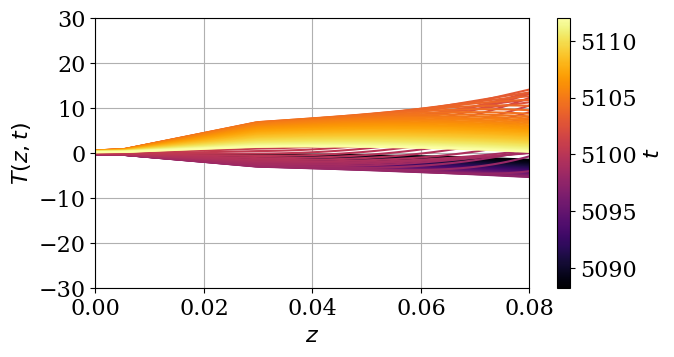

In [142]:
from matplotlib.collections import LineCollection
fig, axsm = plt.subplots(nrows=1,ncols=1,figsize=(7, 3.5))
undersampling = 12
# set axes limits manually because Collections do not take part in autoscaling
axsm.set_xlim(wall.grid.xs[0], wall.grid.xs[-1])
axsm.set_ylim(wall.dump.T[::,:,1].min(), wall.dump.T[:,:,1].max())
# ax.set_aspect("equal")  # to make the arcs look circular
mask = np.where(wall.dump.t > wall.dump.t[-1] - oneday)
# create a LineCollection with the half-circles and color mapping
line_collection = LineCollection(wall.dump.T[mask], array=wall.dump.t[mask]/onehour, cmap="inferno", linewidth=1.5)
axsm.add_collection(line_collection)
# axsm[0].set_xlim(-0.052,0.052)
axsm.set_xlabel(r"$z$")
axsm.set_ylabel(r"$T(z,t)$")
axsm.grid(True)
axsm.set_ylim(-30,30)
fig.colorbar(line_collection, label=r"$t$")
plt.savefig("example.pdf",bbox_inches='tight')
plt.show()